<a href="https://colab.research.google.com/github/renishpatel-12/code-alpha-internship-ml-tasks/blob/main/CodeAlpha_HandwrittenCharacterRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test)=datasets.mnist.load_data()

print(X_train.shape)
print(y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)


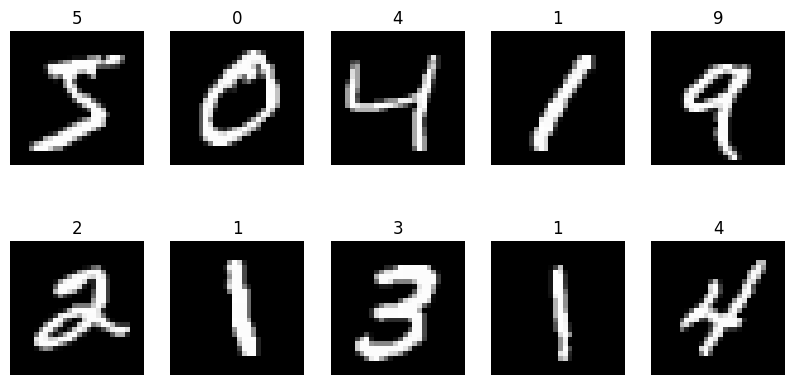

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [4]:
X_train=X_train/255.0
X_test=X_test/255.0

In [5]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

In [6]:
model=models.Sequential()

model.add(
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    layers.MaxPooling2D((2,2))
)

model.add(
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    layers.MaxPooling2D((2,2))
)

model.add(layers.Flatten())

model.add(
    layers.Dense(
        128,
        activation='relu'
    )
)

model.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history=model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9600 - loss: 0.1287 - val_accuracy: 0.9825 - val_loss: 0.0569
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9866 - loss: 0.0424 - val_accuracy: 0.9863 - val_loss: 0.0426
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9901 - loss: 0.0307 - val_accuracy: 0.9904 - val_loss: 0.0312
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9909 - val_loss: 0.0300
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9945 - loss: 0.0166 - val_accuracy: 0.9896 - val_loss: 0.0369


In [9]:
loss,accuracy=model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9896 - loss: 0.0369
Accuracy: 0.9896000027656555


In [10]:
prediction=model.predict(X_test)

import numpy as np

print(
    "Predicted:",
    np.argmax(prediction[0])
)

print(
    "Actual:",
    y_test[0]
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 7
Actual: 7


In [11]:
model.save(
    "handwritten_character_model.h5"
)

In [12]:
from google.colab import files

files.download(
    "handwritten_character_model.h5"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>